## Agentic RAG

Agentic RAG (Retrieval-Augmented-Generation) is a framework that enhances traditional RAG systems by incoporating intelligent agents to handle complex tasks and make decisions dynamically

Use an agent to figure out how to retrieve the most relevant information before using the retreived information to answer the user's question.

Retrieval Agents are useful when we want to nake decisions about whether to retrieve from an index.

To implement a retrieval agent, we simply need to give an LLM access to a retriever tool.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Agentic RAG"

In [3]:
from langchain_groq import ChatGroq
llm = ChatGroq(model= os.getenv('GROQ_MODEL'), api_key= os.getenv('GROQ_API_KEY'), temperature=0.7)

c:\Users\singh\OneDrive\Desktop\Generative-AI-using-LangGraph\LangGraphEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

USER_AGENT environment variable not set, consider setting it to identify your requests.
C:\Users\singh\AppData\Local\Temp\ipykernel_21768\1240894442.py:6: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5145.89it/s]


In [5]:
urls=[
    "https://docs.langchain.com/oss/python/langgraph/quickstart.md",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents.md",
    "https://docs.langchain.com/oss/python/langgraph/use-graph-api.md"
]

docs= [WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/quickstart.md'}, page_content='> ## Documentation Index\n> Fetch the complete documentation index at: https://docs.langchain.com/llms.txt\n> Use this file to discover all available pages before exploring further.\n\n# Quickstart\n\nThis quickstart demonstrates how to build a calculator agent using the LangGraph Graph API or the Functional API.\n\n\n  **Using an AI coding assistant?**\n\n  * Install the [LangChain Docs MCP server](/use-these-docs) to give your agent access to up-to-date LangChain documentation and examples.\n  * Install [LangChain Skills](https://github.com/langchain-ai/langchain-skills) to improve your agent\'s performance on LangChain ecosystem tasks.\n\n\n* [Use the Graph API](#use-the-graph-api) if you prefer to define your agent as a graph of nodes and edges.\n* [Use the Functional API](#use-the-functional-api) if you prefer to define your agent as a single function.\n\nFor conceptual i

In [6]:
doc_list = [item for sublist in docs for item in sublist]
doc_list

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/quickstart.md'}, page_content='> ## Documentation Index\n> Fetch the complete documentation index at: https://docs.langchain.com/llms.txt\n> Use this file to discover all available pages before exploring further.\n\n# Quickstart\n\nThis quickstart demonstrates how to build a calculator agent using the LangGraph Graph API or the Functional API.\n\n\n  **Using an AI coding assistant?**\n\n  * Install the [LangChain Docs MCP server](/use-these-docs) to give your agent access to up-to-date LangChain documentation and examples.\n  * Install [LangChain Skills](https://github.com/langchain-ai/langchain-skills) to improve your agent\'s performance on LangChain ecosystem tasks.\n\n\n* [Use the Graph API](#use-the-graph-api) if you prefer to define your agent as a graph of nodes and edges.\n* [Use the Functional API](#use-the-functional-api) if you prefer to define your agent as a single function.\n\nFor conceptual in

In [7]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
document = splitter.split_documents(doc_list)
print(document)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/quickstart.md'}, page_content="> ## Documentation Index\n> Fetch the complete documentation index at: https://docs.langchain.com/llms.txt\n> Use this file to discover all available pages before exploring further.\n\n# Quickstart\n\nThis quickstart demonstrates how to build a calculator agent using the LangGraph Graph API or the Functional API.\n\n\n  **Using an AI coding assistant?**\n\n  * Install the [LangChain Docs MCP server](/use-these-docs) to give your agent access to up-to-date LangChain documentation and examples.\n  * Install [LangChain Skills](https://github.com/langchain-ai/langchain-skills) to improve your agent's performance on LangChain ecosystem tasks.\n\n\n* [Use the Graph API](#use-the-graph-api) if you prefer to define your agent as a graph of nodes and edges.\n* [Use the Functional API](#use-the-functional-api) if you prefer to define your agent as a single function."), Document(metadata=

In [8]:
vector_store = FAISS.from_documents(
    documents=document, embedding=embeddings
)
retriever = vector_store.as_retriever()

vector_store.save_local('FAISS_DB_LangGraph')

### LangGraph Tool

In [9]:
retriever.invoke("What is LangGraph?")

[Document(id='40e0bff9-0999-4215-972f-9ca71150d9b2', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/use-graph-api.md'}, page_content="**Set up LangSmith for better debugging**\n\n  Sign up for [LangSmith](https://smith.langchain.com?utm_source=docs\\&utm_medium=cta\\&utm_campaign=langsmith-signup\\&utm_content=oss-langgraph-use-graph-api) to quickly spot issues and improve the performance of your LangGraph projects. LangSmith lets you use trace data to debug, test, and monitor your LLM apps built with LangGraph—read more about how to get started in the [docs](/langsmith/observability).\n\n\n## Define and update state\n\nHere we show how to define and update [state](/oss/python/langgraph/graph-api#state) in LangGraph. We will demonstrate:\n\n1. How to use state to define a graph's [schema](/oss/python/langgraph/graph-api#schema)\n2. How to use [reducers](/oss/python/langgraph/graph-api#reducers) to control how state updates are processed.\n\n### Define state"),
 Do

In [10]:
## Retriever to Retriever Tools
from langchain_classic.tools.retriever import create_retriever_tool
retriever_tool = create_retriever_tool(retriever, "retriever_vector_db_blog", "Search and run information about LangGraph")
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about LangGraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x00000228B52AE660>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x00000228B52AE160>)

### LangChain Tool

In [11]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel Context Prot

In [12]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstorelangchain=FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
)

retrieverlangchain=vectorstorelangchain.as_retriever()

vectorstorelangchain.save_local('FAISS_DB_LangChain')

In [13]:
from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [14]:
tools=[retriever_tool, retriever_tool_langchain]

### Workflow

In [15]:
from typing import Annotated, Sequence, Literal
from dataclasses import dataclass
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph.message import add_messages

@dataclass
class AgentState:
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

c:\Users\singh\OneDrive\Desktop\Generative-AI-using-LangGraph\LangGraphEnv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### State Access Pattern

`AgentState` is defined as a Python `@dataclass`, so its fields must be accessed with **dot notation** (`state.messages`), not bracket notation (`state["messages"]`).  
Bracket notation is for `TypedDict`-based states. Using `state["messages"]` on a dataclass raises a `TypeError` at runtime.

All node functions below must use `state.messages`.

In [16]:
llm_with_tools = llm.bind_tools(tools)

def agent(state):
    """Calls the LLM with tools bound. Decides whether to retrieve or respond directly."""
    print("---CALL AGENT---")
    response = llm_with_tools.invoke(state.messages)
    return {"messages": [response]}

In [17]:
from langchain_classic import hub
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import StrOutputParser

### Edge Functions

The three functions below (`grade_documents`, `generate`, `rewrite`) were originally using `state["messages"]` which is incompatible with the `@dataclass` state.  
**Fix applied:** changed to `state.messages` in all three.

In [18]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(
                    model="openai/gpt-oss-120b",
                    api_key=os.getenv('GROQ_API_KEY'), 
                    temperature=0.8)

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state.messages  # dataclass: use dot notation, not state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [19]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state.messages  # dataclass: use dot notation, not state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(
                    model="openai/gpt-oss-120b",
                    api_key=os.getenv('GROQ_API_KEY'), 
                    temperature=0.8)

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [20]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state.messages  # dataclass: use dot notation, not state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(
                    model="openai/gpt-oss-120b",
                    api_key=os.getenv('GROQ_API_KEY'),
                    temperature=0.8)
    
    response = model.invoke(msg)
    return {"messages": [response]}

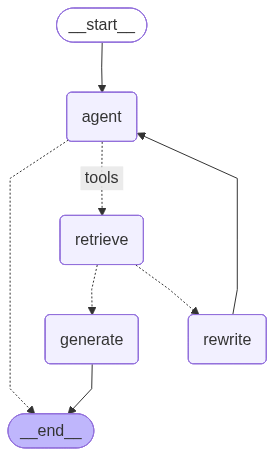

In [21]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [22]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='8d76194c-f107-4609-8640-d7f2b7b9f45a'),
  AIMessage(content='**LangGraph – an overview**\n\nLangGraph (sometimes written *LangGraph*) is an open‑source Python framework for building **state‑driven, graph‑structured workflows** on top of large language models (LLMs). It was created by the same team behind LangChain and is now part of the broader LangChain ecosystem. While LangChain focuses on *chains* (linear or branching sequences of LLM calls), LangGraph adds a **graph abstraction** that makes it easy to model complex, multi‑step, and potentially cyclic interactions such as:\n\n* **Agentic loops** (e.g., “plan → act → observe → re‑plan”)\n* **Dynamic decision trees** (different branches depending on LLM output or external signals)\n* **Recursive or iterative refinement** (e.g., self‑critiquing, tool‑use loops)\n* **Co‑operative multi‑agent systems** (multiple agents passing message

In [23]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='10332ca8-3feb-44e2-a787-ba8d6989c318'),
  AIMessage(content='**LangChain** is an open‑source framework that makes it easy to build applications powered by large language models (LLMs).  \n\n### Core idea\nInstead of treating an LLM as a single “black‑box” that takes a prompt and returns text, LangChain encourages you to **chain together** multiple components—prompts, LLM calls, memory, tools, and data sources—so that the overall system can reason, retrieve information, act on external APIs, and maintain state across interactions.\n\n### Main building blocks\n| Block | What it does | Typical use |\n|-------|--------------|-------------|\n| **PromptTemplate** | Parameterized prompt strings (with variables) | Re‑use and dynamically fill prompts |\n| **LLM / ChatModel** | Wrapper around any LLM provider (OpenAI, Anthropic, Cohere, etc.) | Generate text or chat completions |\n| **Chains*

In [24]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='56893c8e-2f4d-4a80-882d-f1c33fbd0742'),
  AIMessage(content='**Machine learning (ML)** is a subfield of artificial intelligence (AI) that focuses on building systems that can learn from data, identify patterns, and make decisions or predictions with minimal human intervention.\n\n### Core Idea\nInstead of explicitly programming a computer to perform a task step‑by‑step, you give it **examples** (data) and let it **infer** the underlying rules or relationships. The system then uses what it has learned to handle new, unseen situations.\n\n### How It Works (High‑Level Steps)\n\n| Step | Description |\n|------|--------------|\n| **1. Data Collection** | Gather relevant data (e.g., images, text, sensor readings). |\n| **2. Data Preparation** | Clean, label, and transform the data into a format suitable for modeling. |\n| **3. Model Selection** | Choose a mathematical model/algorit